# Velocity-Aware Geo-Indistinguishability for Multi-Modal Transportation Privacy-Preserving System

This notebook proposes a privacy-preserving system that adapts Location Privacy Protection Mechanisms (LPPMs) according to different transportation modes (e.g., walking, biking, driving, public transport). It integrates a velocity-aware geo-indistinguishability mechanism that customizes noise injection and prediction strategies to provide a fine-grained balance between privacy and utility.

## Objectives

- Transport-Mode Aware LPPM: Apply different geo-indistinguishability parameters for walking, driving, metro, etc.

- Velocity-Aware Tuning: Configure the epsilon value based on current or predicted velocity/duration/distance.

- Hourly Prediction Integration: Adjust privacy settings based on time-slot frequency usage (e.g., commuting hours).

- Attack Simulation Framework: Evaluate sensitivity to re-identification, trajectory linkage, and semantic location attacks.

- Privacy–Utility Tradeoff Analysis: Balance between service accuracy and privacy level.

In [1]:
# contains multiple constant variables that result in a less verbose coding
import privkit as pk
import pandas as pd
import numpy as np
from datetime import datetime
from geopy.distance import geodesic
from privkit.utils import constants
import matplotlib.pyplot as plt
import seaborn as sns
from privkit.utils import (
    geo_utils,
    constants,
)
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import display
import os

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2025-07-09 19:42:39.177479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752082959.192102   22514 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752082959.196316   22514 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752082959.208558   22514 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752082959.208577   22514 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752082959.208579   22514 computation_placer.cc:177] computation placer alr

In [9]:
# ---- Parameters ----
# id of the dataset
file = 'geolife'
# list of the id's of each ppm
ppms = ['clustering']
# list of the id's of each scenario
scenarios = ['high_vu_high_vr', 'high_vu_low_vr', 'low_vu_high_vr', 'low_vu_low_vr']

In [3]:
# ---- Load Dataset ----
dataset = pk.datasets.GeolifeDataset()
dataset.load_dataset()
# Extract all labeled transport data
all_data = dataset.data.data  # Access the DataFrame within the LocationData object
labeled_data = all_data[all_data['label'].notnull()].copy()
# Get list of unique transport modes (e.g., 'walk', 'car', 'bus', ...)
transport_modes = labeled_data['label'].unique()
print(f"Unique transport modes: {transport_modes}")

Loading the geolife dataset
Dataset loaded from ./input/data/geolife.pkl
Unique transport modes: ['car' 'walk' 'subway' 'bus' 'taxi' 'train' 'bike' 'boat' 'run' 'airplane'
 'motorcycle']


In [4]:
# --- Create a function to apply different PPMs to each scenario ---
def apply_ppm_to_scenario(ppm, location_data):
    # privacy parameter to be used in the appliance of the PPMs
    epsilon = 0.016
    
    if ppm == 'planar_laplace':
        planar_laplace = pk.PlanarLaplace(epsilon=epsilon)
        location_data = planar_laplace.execute(location_data)
        quality_loss = location_data.data.get(constants.QUALITY_LOSS)
        return location_data, quality_loss

    elif ppm == 'clustering':
        r = np.log(4) / epsilon
        clustering = pk.ClusteringGeoInd(r=r, epsilon=epsilon)
        location_data = clustering.execute(location_data)
        quality_loss = location_data.data.get(constants.QUALITY_LOSS)
        return location_data, quality_loss

    elif ppm == 'adaptive':
        ws = 2
        delta1 = 124.29
        delta2 = 428.56
        adaptive = pk.AdaptiveGeoInd(epsilon=epsilon, ws=ws, delta1=delta1, delta2=delta2)
        location_data = adaptive.execute(location_data)
        quality_loss = location_data.data.get(constants.QUALITY_LOSS)
        return location_data, quality_loss

    elif ppm == 'va_gi':
        m = 10
        va_gi = pk.VAGI(epsilon=epsilon, m=m)
        location_data, quality_loss = va_gi.execute(location_data)
        return location_data, quality_loss

    return None, None

In [ ]:
# ---- Main Execution ----
# Create privacy parameter to be used in the appliance of the PPMs
epsilon = 0.016
# Loop over each transport mode
for transport_mode in tqdm(transport_modes, desc="Transport Modes"):
    print(f"[INFO] Processing transport mode: {transport_mode}")
    
    # Filter data for this transport mode
    mode_data = labeled_data[labeled_data['label'] == transport_mode].reset_index(drop=True)
    
    # Wrap into LocationData object
    location_data_per_transport_mode = pk.LocationData(id_name=transport_mode)
    location_data_per_transport_mode.data = mode_data
    
    # Iterate over every pair of scenario and ppm with tqdm for better progress tracking
    for scenario in tqdm(scenarios, desc=f"Scenarios for {transport_mode}", leave=False):
        for ppm in tqdm(ppms, desc=f"PPMs for {scenario}", leave=False):
            # Load data
            location_data = pk.LocationData('{}_{}'.format(scenario, ppm))
            location_data.data = location_data_per_transport_mode.data.copy()
            
            # Apply PPM to the scenario
            location_data, quality_loss_values = apply_ppm_to_scenario(ppm, location_data)
            
            if quality_loss_values is not None:            

                # Save quality loss values
                filepath = '{}{}/{}/{}/'.format(constants.output_folder, file, transport_mode, ppm)
                # Ensure the directory exists
                os.makedirs(filepath, exist_ok=True)
                filename = 'ql_{}_e{}'.format(scenario, int(epsilon * 1000))
                np.save(filepath + filename, quality_loss_values)
                print(f"[INFO] Quality loss values saved for {transport_mode}, {scenario} with {ppm}.")
            else:
                print(f"[WARNING] No quality loss values returned for {transport_mode}, {scenario} with {ppm}.")

Transport Modes:   0%|          | 0/11 [00:00<?, ?it/s]

[INFO] Processing transport mode: car


[INFO] Quality loss values saved for car, high_vu_high_vr with clustering.


[INFO] Quality loss values saved for car, high_vu_low_vr with clustering.


[INFO] Quality loss values saved for car, low_vu_high_vr with clustering.





Transport Modes:   9%|▉         | 1/11 [00:16<02:49, 16.99s/it]

[INFO] Quality loss values saved for car, low_vu_low_vr with clustering.
[INFO] Processing transport mode: walk


[INFO] Quality loss values saved for walk, high_vu_high_vr with clustering.


## Privacy–Utility Tradeoff Analysis: Visualizing the Results
We now present a simple script that generates a *matplotlib* box plot graph, showing the behavior of each scenario under the different PPMs. 


[PLOT] Generating plot for transport mode: car


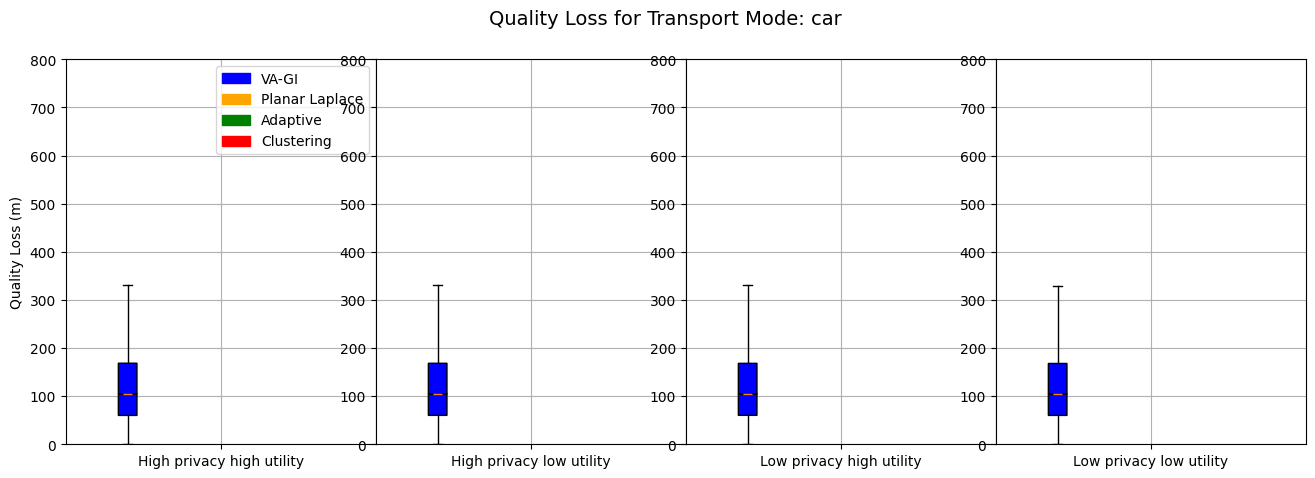

[PLOT] Generating plot for transport mode: walk


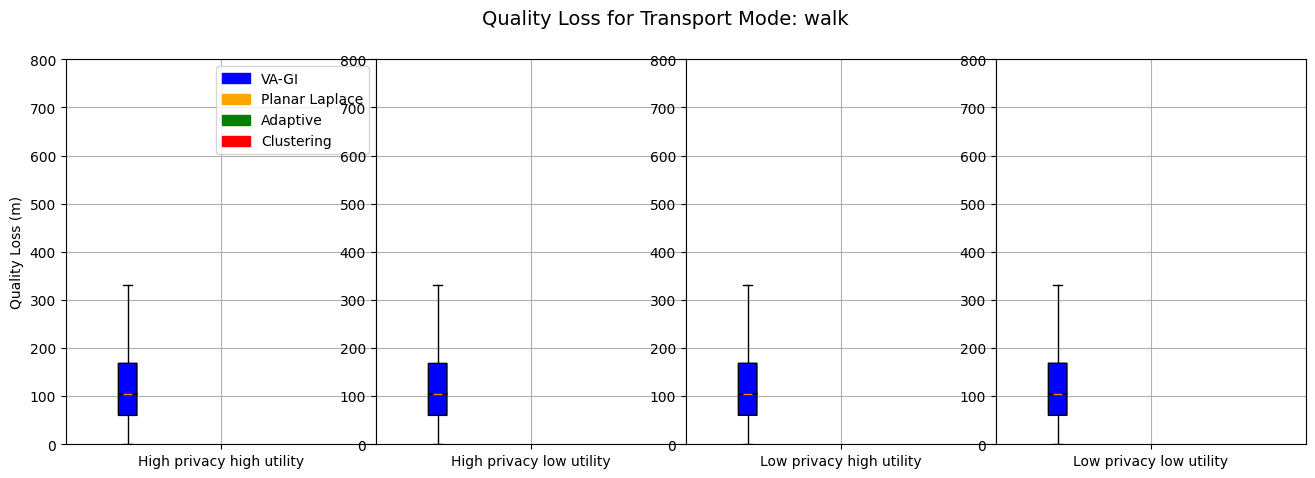

[PLOT] Generating plot for transport mode: subway


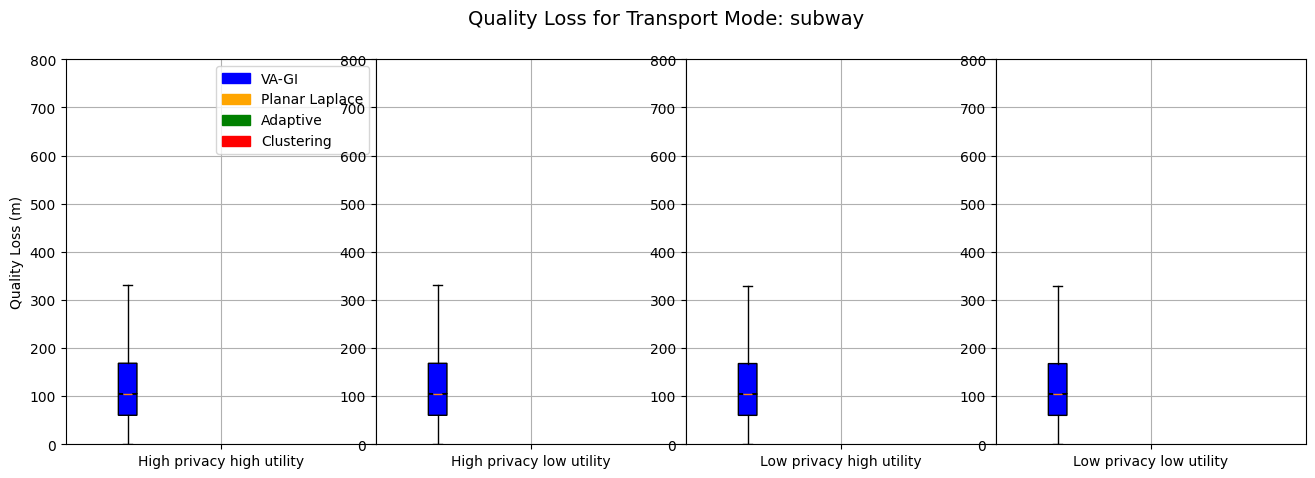

[PLOT] Generating plot for transport mode: bus


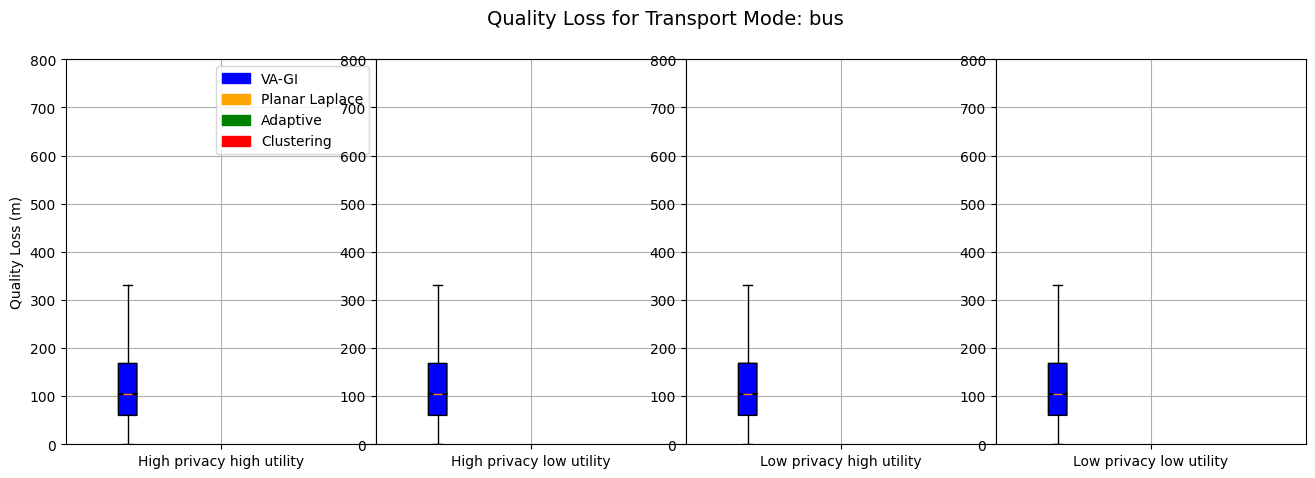

[PLOT] Generating plot for transport mode: taxi


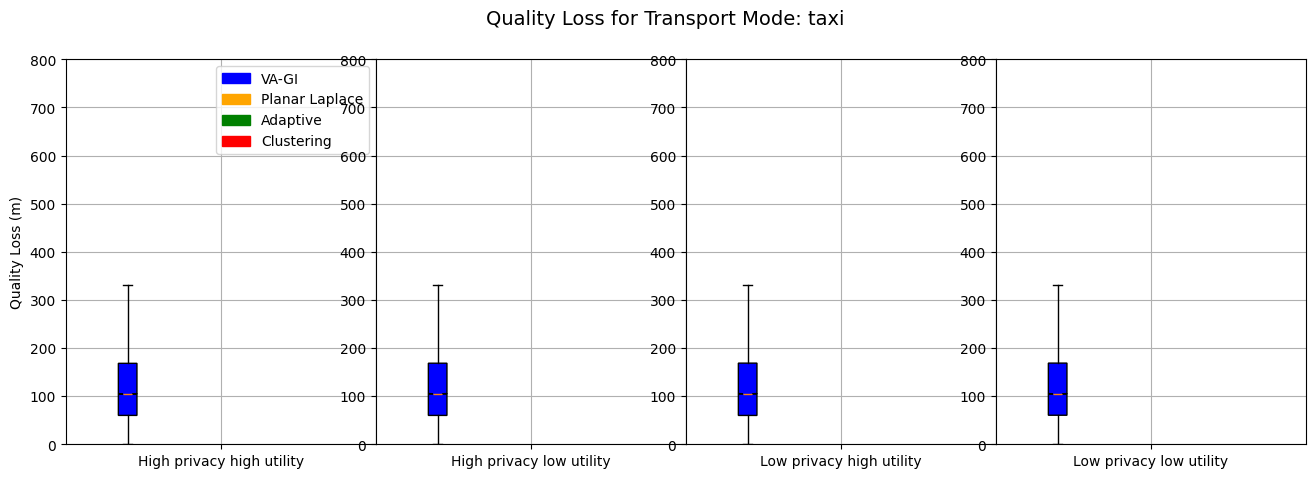

[PLOT] Generating plot for transport mode: train


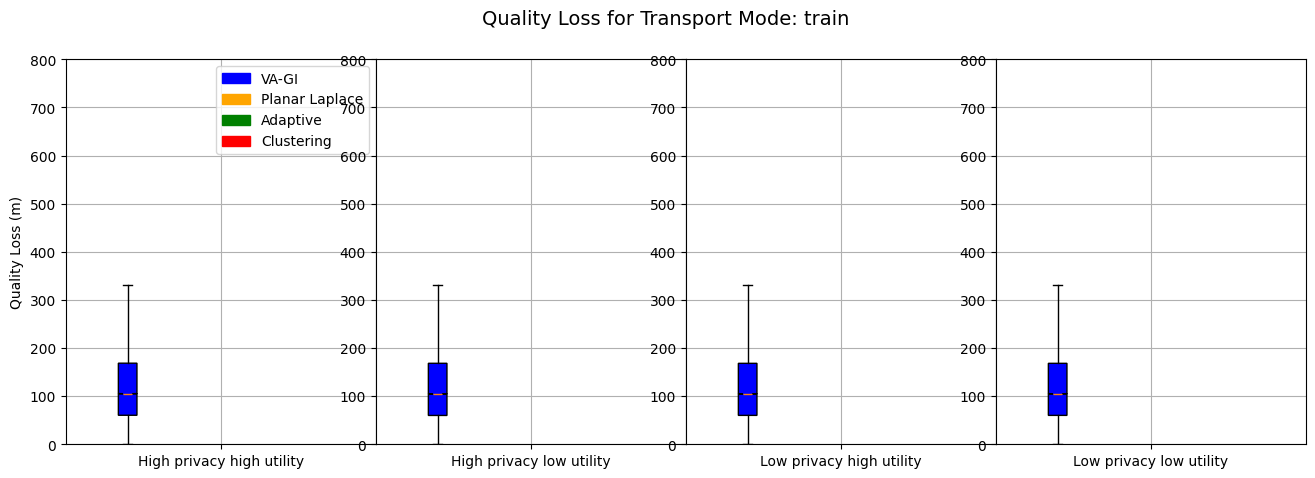

[PLOT] Generating plot for transport mode: bike


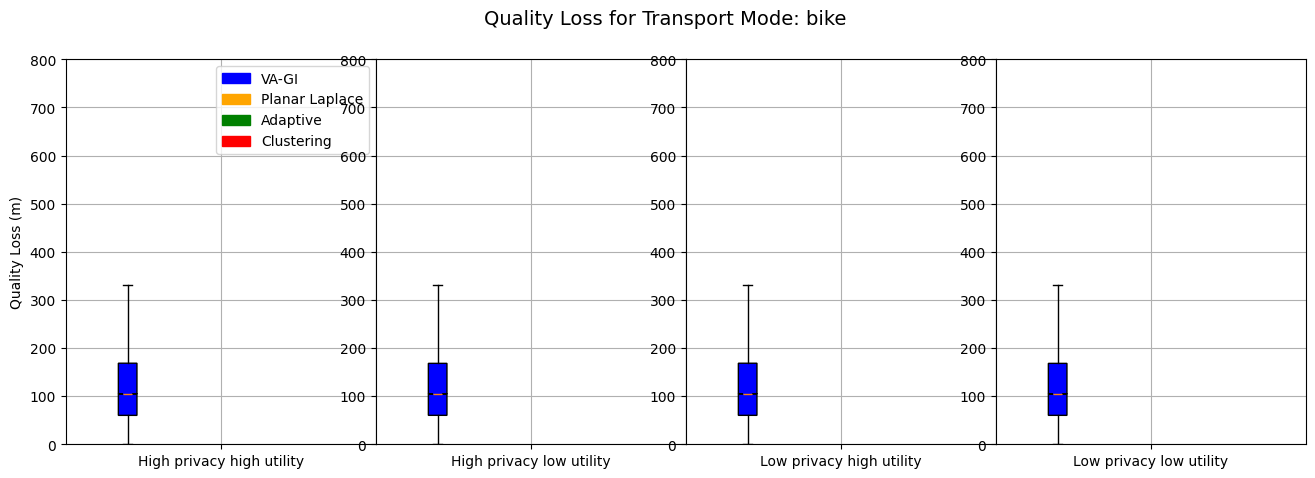

[PLOT] Generating plot for transport mode: boat


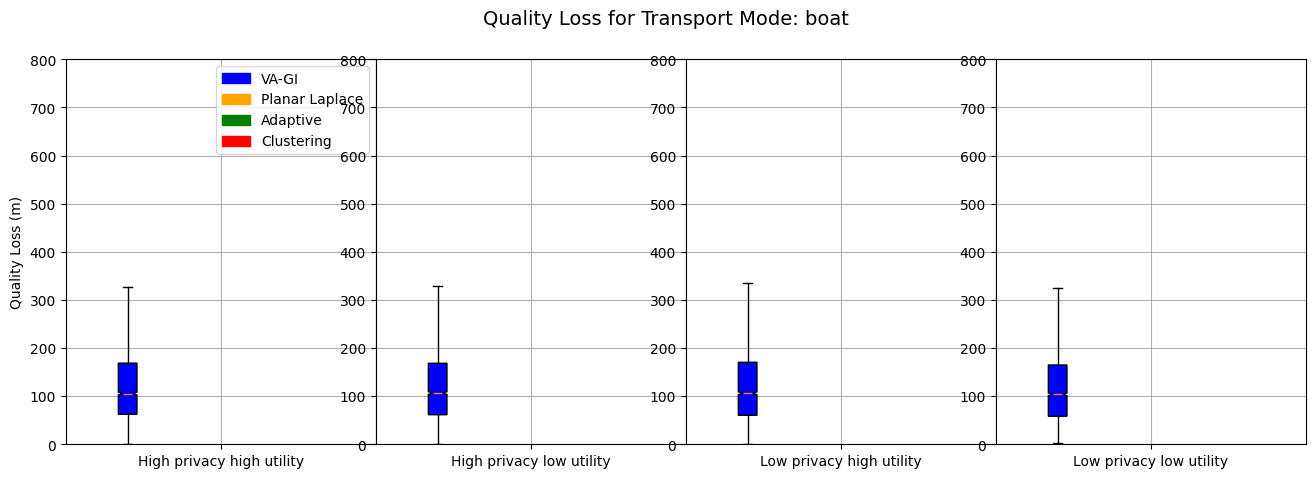

[PLOT] Generating plot for transport mode: run


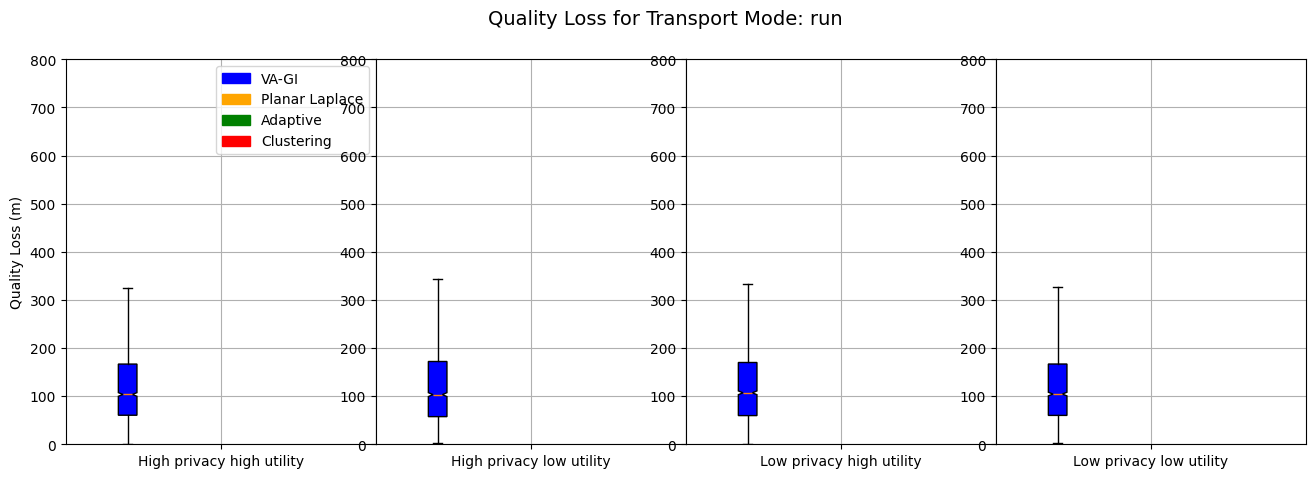

[PLOT] Generating plot for transport mode: airplane


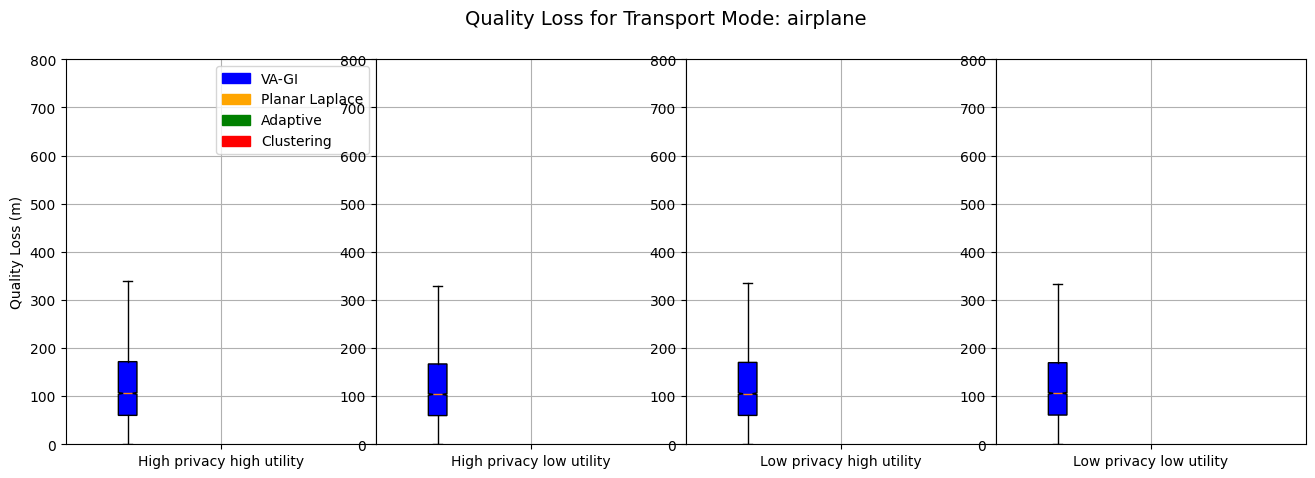

[PLOT] Generating plot for transport mode: motorcycle


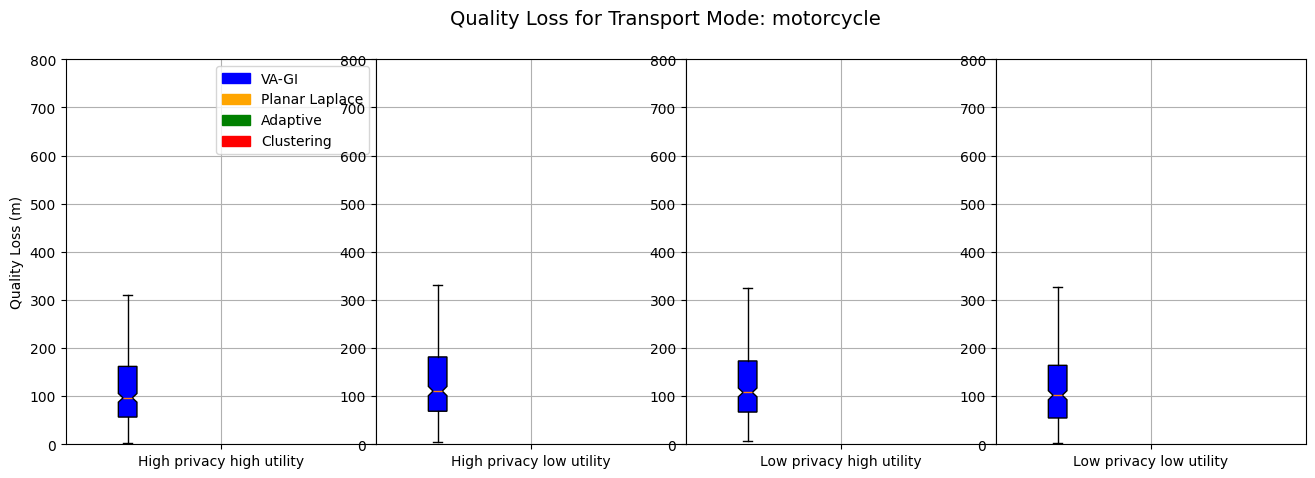

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# scenarios labels
scenarios_labels = [r'$\uparrow v_u \downarrow v_r$', 
                    r'$\downarrow v_u \downarrow v_r$', 
                    r'$\uparrow v_u \uparrow v_r$', 
                    r'$\downarrow v_u \uparrow v_r$']

# ppms colors
colors = ['blue', 'orange', 'green', 'red']

# ppms labels
ppms_labels = ['VA-GI', 'Planar Laplace', 'Adaptive', 'Clustering']

# set epsilon value
epsilon = 0.016

# senarios labels
scenarios_labels = ['High privacy high utility',
                    'High privacy low utility',
                    'Low privacy high utility',
                    'Low privacy low utility']
# Iterate over each transport_mode
for transport_mode in transport_modes:
    print(f"[PLOT] Generating plot for transport mode: {transport_mode}")
    
    # Initialize figure with 4 subplots (1 for each scenario)
    plt.figure(figsize=(16, 5))
    plt.suptitle(f'Quality Loss for Transport Mode: {transport_mode}', fontsize=14)

    for index, (scenario, scenario_label) in enumerate(zip(scenarios, scenarios_labels)):
        plt.subplot(1, 4, index + 1)

        # Load quality loss data for each PPM
        ql_data = []
        for ppm in ppms:
            filepath = f'{constants.output_folder}{file}/{transport_mode}/{ppm}/ql_{scenario}_e{int(epsilon*1000)}.npy'
            if os.path.exists(filepath):
                data = np.load(filepath)
                ql_data.append(data)
            else:
                print(f"[WARNING] File not found: {filepath}")
                ql_data.append([])

        # Plot boxplots for each PPM
        boxplots = []
        for i, data in enumerate(ql_data):
            bp = plt.boxplot(data, positions=[-1 + i*2/3], widths=0.20, notch=True,
                             patch_artist=True, showfliers=False)
            boxplots.append(bp)

        # Set colors
        for plot, color in zip(boxplots, colors):
            for patch in plot['boxes']:
                patch.set_facecolor(color)

        # Labeling
        plt.xticks(np.arange(0, 2, 2), [scenario_label])
        plt.axis(xmin=-2, xmax=2)
        plt.xlim([-1-2/3, 1+2/3])
        plt.ylim([0, 800])
        plt.grid(True)

    # Add ylabel to first subplot
    plt.subplot(1, 4, 1)
    plt.ylabel('Quality Loss (m)')

    # Add legend
    handles = [mpatches.Patch(color=color, label=label) for color, label in zip(colors, ppms_labels)]
    plt.legend(handles=handles, loc='upper right')

    plt.subplots_adjust(wspace=.0)
    plt.show()
